In [1]:
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
from azure.ai.vision.imageanalysis.models import VisualFeatures

from msrest.authentication import CognitiveServicesCredentials
from array import array
import os
from PIL import Image
import sys
import time
import matplotlib.pyplot as plt
from skimage import io
import numpy as np

In [2]:
subscription_key = os.environ["VISION_KEY"]
endpoint = os.environ["VISION_ENDPOINT"]
computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))

In [149]:
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

folder = Path("images")
file_names = [f.name for f in folder.iterdir() if f.is_file()]
relevant_tags_or_objects = ["bike", "bicycle"]

preds = []
real_data = [1 if "bike" in file_name else 0 for file_name in file_names]
for img_path in file_names:
    with open(folder / img_path, "rb") as img:
        result = computervision_client.analyze_image_in_stream(
            img, visual_features=[VisualFeatureTypes.tags, VisualFeatureTypes.objects]
        )
        found = False
        for tag in result.tags:
            if tag.name.lower() in relevant_tags_or_objects:
                found = True
        for ob in result.objects:
            if ob.object_property.lower() in relevant_tags_or_objects:
                found = True
        preds.append(1 if found else 0)
        

print("Acuratete:", accuracy_score(real_data, preds))

Acuratete: 1.0


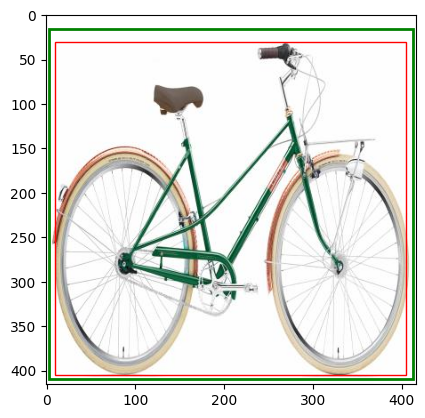

IoU: 0.9191974979211398
MSE: 79.75


In [52]:
bike_bb = [10.0, 30.0, 405.0, 405.0]
img = open("images/bike1.jpg", "rb")
result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
for ob in result.objects:
    if (ob.object_property in relevant_tags_or_objects):
        predicted_bike_bb = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.x + ob.rectangle.w, ob.rectangle.y + ob.rectangle.h]

im = plt.imread("images/bike1.jpg")
fig = plt.imshow(im)
fig.axes.add_patch(plt.Rectangle(xy = (bike_bb[0], bike_bb[1]), width = bike_bb[2]-bike_bb[0], height = bike_bb[3]-bike_bb[1], fill = False, color = "red", linewidth = 1))
fig.axes.add_patch(plt.Rectangle(xy = (predicted_bike_bb[0], predicted_bike_bb[1]), width = predicted_bike_bb[2]-predicted_bike_bb[0], height = predicted_bike_bb[3]-predicted_bike_bb[1], fill = False, color = "green", linewidth = 2))
plt.show()

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def compute_mse(boxA, boxB):
    return sum((a - b) ** 2 for a, b in zip(boxA, boxB)) / 4

iou = compute_iou(bike_bb, predicted_bike_bb)
mse = compute_mse(bike_bb, predicted_bike_bb)
print("IoU:", iou)
print("MSE:", mse)

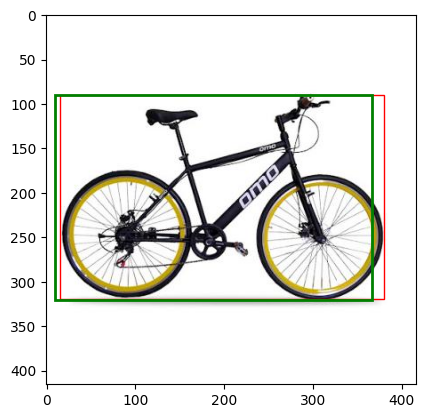

IoU: 0.9421499177238087
MSE: 58.25


In [64]:
bike_bb = [15.0, 90.0, 380.0, 320.0]
img = open("images/bike02.jpg", "rb")
result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
for ob in result.objects:
    if (ob.object_property in relevant_tags_or_objects):
        predicted_bike_bb = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.x + ob.rectangle.w, ob.rectangle.y + ob.rectangle.h]

im = plt.imread("images/bike02.jpg")
fig = plt.imshow(im)
fig.axes.add_patch(plt.Rectangle(xy = (bike_bb[0], bike_bb[1]), width = bike_bb[2]-bike_bb[0], height = bike_bb[3]-bike_bb[1], fill = False, color = "red", linewidth = 1))
fig.axes.add_patch(plt.Rectangle(xy = (predicted_bike_bb[0], predicted_bike_bb[1]), width = predicted_bike_bb[2]-predicted_bike_bb[0], height = predicted_bike_bb[3]-predicted_bike_bb[1], fill = False, color = "green", linewidth = 2))
plt.show()

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def compute_mse(boxA, boxB):
    return sum((a - b) ** 2 for a, b in zip(boxA, boxB)) / 4

iou = compute_iou(bike_bb, predicted_bike_bb)
mse = compute_mse(bike_bb, predicted_bike_bb)
print("IoU:", iou)
print("MSE:", mse)

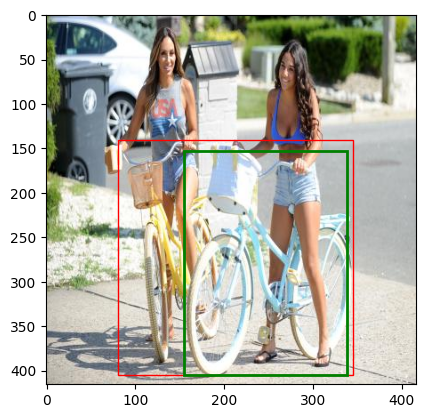

IoU: 0.656689213243147
MSE: 1460.75


In [81]:
bike_bb = [80.0, 140.0, 345.0, 405.0]
img = open("images/bike03.jpg", "rb")
result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
for ob in result.objects:
    if (ob.object_property in relevant_tags_or_objects):
        predicted_bike_bb = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.x + ob.rectangle.w, ob.rectangle.y + ob.rectangle.h]

im = plt.imread("images/bike03.jpg")
fig = plt.imshow(im)
fig.axes.add_patch(plt.Rectangle(xy = (bike_bb[0], bike_bb[1]), width = bike_bb[2]-bike_bb[0], height = bike_bb[3]-bike_bb[1], fill = False, color = "red", linewidth = 1))
fig.axes.add_patch(plt.Rectangle(xy = (predicted_bike_bb[0], predicted_bike_bb[1]), width = predicted_bike_bb[2]-predicted_bike_bb[0], height = predicted_bike_bb[3]-predicted_bike_bb[1], fill = False, color = "green", linewidth = 2))
plt.show()

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def compute_mse(boxA, boxB):
    return sum((a - b) ** 2 for a, b in zip(boxA, boxB)) / 4

iou = compute_iou(bike_bb, predicted_bike_bb)
mse = compute_mse(bike_bb, predicted_bike_bb)
print("IoU:", iou)
print("MSE:", mse)

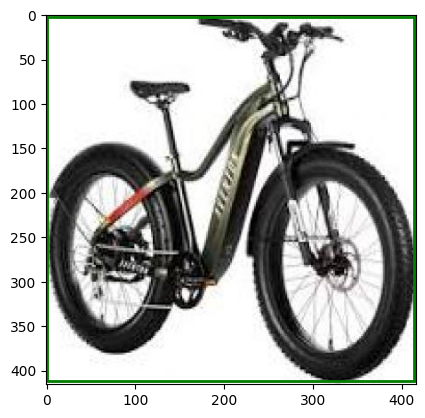

IoU: 0.9927476897882793
MSE: 1.25


In [89]:
bike_bb = [0.0, 0.0, 415.0, 412.0]
img = open("images/bike04.jpg", "rb")
result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
for ob in result.objects:
    if (ob.object_property in relevant_tags_or_objects):
        predicted_bike_bb = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.x + ob.rectangle.w, ob.rectangle.y + ob.rectangle.h]

im = plt.imread("images/bike04.jpg")
fig = plt.imshow(im)
fig.axes.add_patch(plt.Rectangle(xy = (bike_bb[0], bike_bb[1]), width = bike_bb[2]-bike_bb[0], height = bike_bb[3]-bike_bb[1], fill = False, color = "red", linewidth = 1))
fig.axes.add_patch(plt.Rectangle(xy = (predicted_bike_bb[0], predicted_bike_bb[1]), width = predicted_bike_bb[2]-predicted_bike_bb[0], height = predicted_bike_bb[3]-predicted_bike_bb[1], fill = False, color = "green", linewidth = 2))
plt.show()

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def compute_mse(boxA, boxB):
    return sum((a - b) ** 2 for a, b in zip(boxA, boxB)) / 4

iou = compute_iou(bike_bb, predicted_bike_bb)
mse = compute_mse(bike_bb, predicted_bike_bb)
print("IoU:", iou)
print("MSE:", mse)

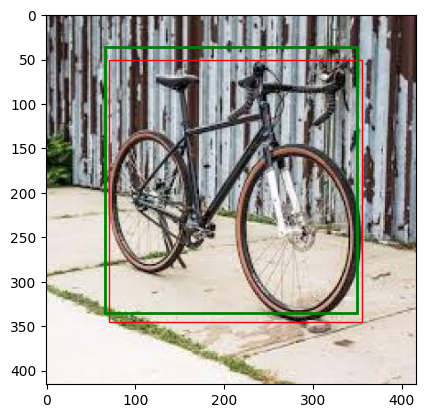

IoU: 0.8916536775177456
MSE: 87.0


In [97]:
bike_bb = [70.0, 50.0, 355.0, 345.0]
img = open("images/bike05.jpg", "rb")
result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
for ob in result.objects:
    if (ob.object_property in relevant_tags_or_objects):
        predicted_bike_bb = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.x + ob.rectangle.w, ob.rectangle.y + ob.rectangle.h]

im = plt.imread("images/bike05.jpg")
fig = plt.imshow(im)
fig.axes.add_patch(plt.Rectangle(xy = (bike_bb[0], bike_bb[1]), width = bike_bb[2]-bike_bb[0], height = bike_bb[3]-bike_bb[1], fill = False, color = "red", linewidth = 1))
fig.axes.add_patch(plt.Rectangle(xy = (predicted_bike_bb[0], predicted_bike_bb[1]), width = predicted_bike_bb[2]-predicted_bike_bb[0], height = predicted_bike_bb[3]-predicted_bike_bb[1], fill = False, color = "green", linewidth = 2))
plt.show()

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def compute_mse(boxA, boxB):
    return sum((a - b) ** 2 for a, b in zip(boxA, boxB)) / 4

iou = compute_iou(bike_bb, predicted_bike_bb)
mse = compute_mse(bike_bb, predicted_bike_bb)
print("IoU:", iou)
print("MSE:", mse)

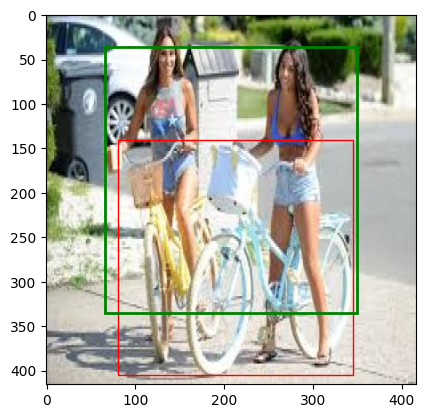

IoU: 0.5008869115124022
MSE: 3982.0


In [ ]:
bike_bb = [80.0, 140.0, 345.0, 405.0]
img = open("images/bike06.jpg", "rb")
result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
for ob in result.objects:
    if (ob.object_property in relevant_tags_or_objects):
        predicted_bike_bb = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.x + ob.rectangle.w, ob.rectangle.y + ob.rectangle.h]

im = plt.imread("images/bike06.jpg")
fig = plt.imshow(im)
fig.axes.add_patch(plt.Rectangle(xy = (bike_bb[0], bike_bb[1]), width = bike_bb[2]-bike_bb[0], height = bike_bb[3]-bike_bb[1], fill = False, color = "red", linewidth = 1))
fig.axes.add_patch(plt.Rectangle(xy = (predicted_bike_bb[0], predicted_bike_bb[1]), width = predicted_bike_bb[2]-predicted_bike_bb[0], height = predicted_bike_bb[3]-predicted_bike_bb[1], fill = False, color = "green", linewidth = 2))
plt.show()

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def compute_mse(boxA, boxB):
    return sum((a - b) ** 2 for a, b in zip(boxA, boxB)) / 4

iou = compute_iou(bike_bb, predicted_bike_bb)
mse = compute_mse(bike_bb, predicted_bike_bb)
print("IoU:", iou)
print("MSE:", mse)

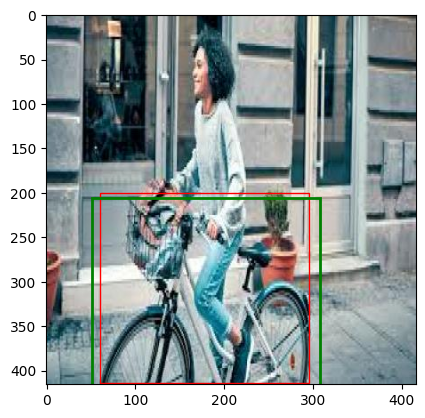

IoU: 0.8826291079812206
MSE: 72.5


In [110]:
bike_bb = [60.0, 200.0, 295.0, 414.0]
img = open("images/bike07.jpg", "rb")
result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
for ob in result.objects:
    if (ob.object_property in relevant_tags_or_objects):
        predicted_bike_bb = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.x + ob.rectangle.w, ob.rectangle.y + ob.rectangle.h]

im = plt.imread("images/bike07.jpg")
fig = plt.imshow(im)
fig.axes.add_patch(plt.Rectangle(xy = (bike_bb[0], bike_bb[1]), width = bike_bb[2]-bike_bb[0], height = bike_bb[3]-bike_bb[1], fill = False, color = "red", linewidth = 1))
fig.axes.add_patch(plt.Rectangle(xy = (predicted_bike_bb[0], predicted_bike_bb[1]), width = predicted_bike_bb[2]-predicted_bike_bb[0], height = predicted_bike_bb[3]-predicted_bike_bb[1], fill = False, color = "green", linewidth = 2))
plt.show()

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def compute_mse(boxA, boxB):
    return sum((a - b) ** 2 for a, b in zip(boxA, boxB)) / 4

iou = compute_iou(bike_bb, predicted_bike_bb)
mse = compute_mse(bike_bb, predicted_bike_bb)
print("IoU:", iou)
print("MSE:", mse)

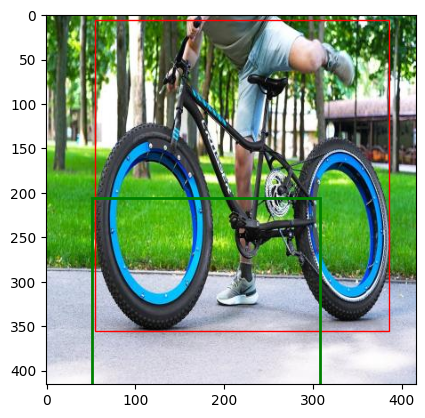

IoU: 0.28607529615323324
MSE: 12516.75


In [126]:
bike_bb = [55.0, 5.0, 385.0, 355.0]
img = open("images/bike08.jpg", "rb")
result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
for ob in result.objects:
    if (ob.object_property in relevant_tags_or_objects):
        predicted_bike_bb = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.x + ob.rectangle.w, ob.rectangle.y + ob.rectangle.h]

im = plt.imread("images/bike08.jpg")
fig = plt.imshow(im)
fig.axes.add_patch(plt.Rectangle(xy = (bike_bb[0], bike_bb[1]), width = bike_bb[2]-bike_bb[0], height = bike_bb[3]-bike_bb[1], fill = False, color = "red", linewidth = 1))
fig.axes.add_patch(plt.Rectangle(xy = (predicted_bike_bb[0], predicted_bike_bb[1]), width = predicted_bike_bb[2]-predicted_bike_bb[0], height = predicted_bike_bb[3]-predicted_bike_bb[1], fill = False, color = "green", linewidth = 2))
plt.show()

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def compute_mse(boxA, boxB):
    return sum((a - b) ** 2 for a, b in zip(boxA, boxB)) / 4

iou = compute_iou(bike_bb, predicted_bike_bb)
mse = compute_mse(bike_bb, predicted_bike_bb)
print("IoU:", iou)
print("MSE:", mse)

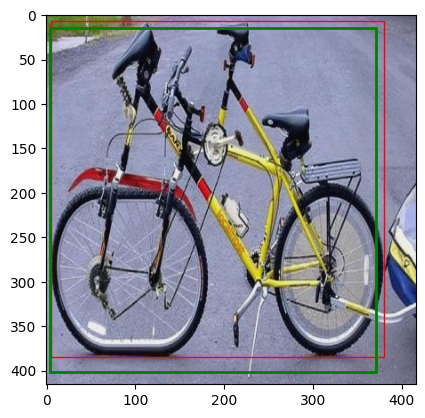

IoU: 0.9152466972229711
MSE: 105.0


In [135]:
bike_bb = [5.0, 7.0, 380.0, 385.0]
img = open("images/bike09.jpg", "rb")
result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
for ob in result.objects:
    if (ob.object_property in relevant_tags_or_objects):
        predicted_bike_bb = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.x + ob.rectangle.w, ob.rectangle.y + ob.rectangle.h]

im = plt.imread("images/bike09.jpg")
fig = plt.imshow(im)
fig.axes.add_patch(plt.Rectangle(xy = (bike_bb[0], bike_bb[1]), width = bike_bb[2]-bike_bb[0], height = bike_bb[3]-bike_bb[1], fill = False, color = "red", linewidth = 1))
fig.axes.add_patch(plt.Rectangle(xy = (predicted_bike_bb[0], predicted_bike_bb[1]), width = predicted_bike_bb[2]-predicted_bike_bb[0], height = predicted_bike_bb[3]-predicted_bike_bb[1], fill = False, color = "green", linewidth = 2))
plt.show()

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def compute_mse(boxA, boxB):
    return sum((a - b) ** 2 for a, b in zip(boxA, boxB)) / 4

iou = compute_iou(bike_bb, predicted_bike_bb)
mse = compute_mse(bike_bb, predicted_bike_bb)
print("IoU:", iou)
print("MSE:", mse)

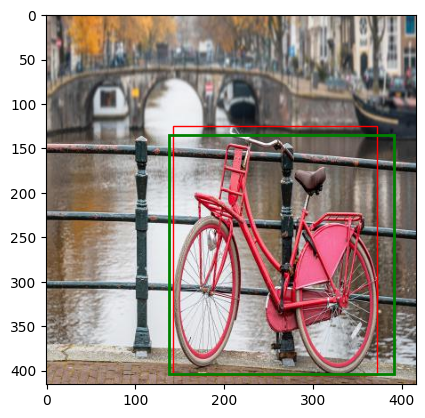

IoU: 0.8765070055392636
MSE: 119.5


In [147]:
bike_bb = [142.0, 125.0, 372.0, 405.0]
img = open("images/bike10.jpg", "rb")
result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.objects])
for ob in result.objects:
    if (ob.object_property in relevant_tags_or_objects):
        predicted_bike_bb = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.x + ob.rectangle.w, ob.rectangle.y + ob.rectangle.h]

im = plt.imread("images/bike10.jpg")
fig = plt.imshow(im)
fig.axes.add_patch(plt.Rectangle(xy = (bike_bb[0], bike_bb[1]), width = bike_bb[2]-bike_bb[0], height = bike_bb[3]-bike_bb[1], fill = False, color = "red", linewidth = 1))
fig.axes.add_patch(plt.Rectangle(xy = (predicted_bike_bb[0], predicted_bike_bb[1]), width = predicted_bike_bb[2]-predicted_bike_bb[0], height = predicted_bike_bb[3]-predicted_bike_bb[1], fill = False, color = "green", linewidth = 2))
plt.show()

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def compute_mse(boxA, boxB):
    return sum((a - b) ** 2 for a, b in zip(boxA, boxB)) / 4

iou = compute_iou(bike_bb, predicted_bike_bb)
mse = compute_mse(bike_bb, predicted_bike_bb)
print("IoU:", iou)
print("MSE:", mse)